
SIMULAÇÃO CINÉTICA COM PYOMO - MODELO PFR
Constantes cinéticas: k1=1.0, k2=0.8, k3=0.5, k4=0.3
Esquema reacional: H → D → Q → N → G
Produto desejado: Q (Jet Fuel)

Processando simulações...
  Simulando WHSV = 0.5 h⁻¹...
    Conversão = 86.2%
    Rendimento = 35.0%

  Simulando WHSV = 1.0 h⁻¹...
    Conversão = 63.0%
    Rendimento = 18.6%

  Simulando WHSV = 2.0 h⁻¹...
    Conversão = 39.3%
    Rendimento = 6.8%

  Simulando WHSV = 3.0 h⁻¹...
    Conversão = 28.3%
    Rendimento = 3.5%

  Simulando WHSV = 4.0 h⁻¹...
    Conversão = 22.1%
    Rendimento = 2.1%

  Simulando WHSV = 5.0 h⁻¹...
    Conversão = 18.1%
    Rendimento = 1.4%


RESUMO DOS RESULTADOS
WHSV (h⁻¹)   Conversão (%)   Rendimento (%) 
--------------------------------------------------
0.5          86.2            35.0           
1.0          63.0            18.6           
2.0          39.3            6.8            
3.0          28.3            3.5            
4.0          22.1            2.1            
5.0          

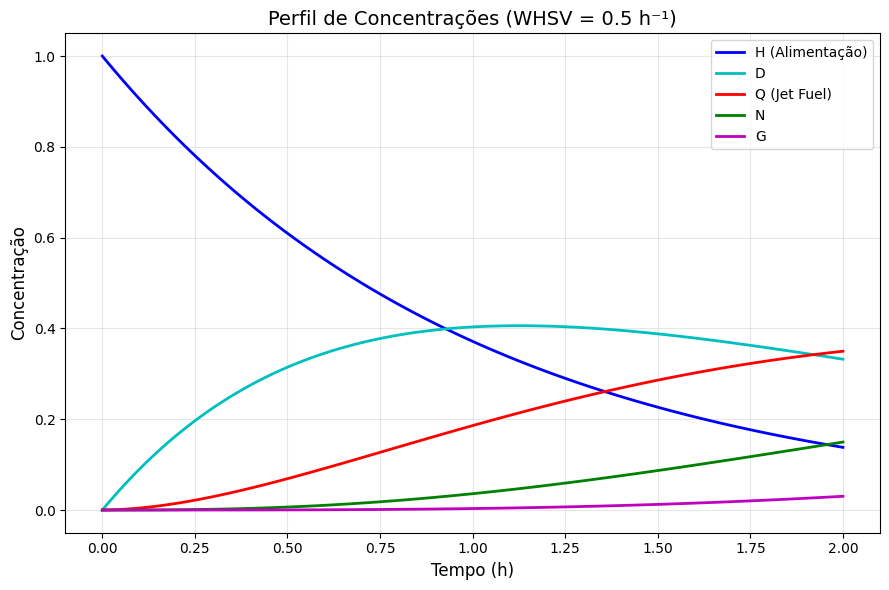


 INTERPRETAÇÃO DOS RESULTADOS

- O rendimento máximo de Q (Jet Fuel) ocorre em WHSV = 0.5 h⁻¹
- Neste ponto, o equilíbrio entre conversão e seletividade é ótimo
- Para WHSV menores: maior tempo de residência → maior conversão,
  mas pode degradar Q em produtos indesejados (N e G)
- Para WHSV maiores: menor tempo de residência → menor conversão,
  resultando em menos Q formado



In [14]:
from pyomo.environ import *
import pyomo.environ as pyo
from pyomo.dae import *
import matplotlib.pyplot as plt
import numpy as np


# MODELO CINÉTICO COM PYOMO 
def simular_reator(WHSV, k1, k2, k3, k4, nfe=100):
    """
    Simula reator PFR com cinética em série usando Pyomo
    Reação: H -> D -> Q -> N -> G
    Q é o produto desejado (Jet Fuel)
    """
    model = pyo.ConcreteModel()
    
    # Tempo espacial = 1/WHSV
    t_final = 1/WHSV
    
    # Domínio temporal
    model.t = ContinuousSet(bounds=(0, t_final))
    
    # Componentes
    model.comp = pyo.Set(initialize=['H', 'D', 'Q', 'N', 'G'])
    
    # Variáveis de concentração
    model.C = pyo.Var(model.comp, model.t, within=pyo.NonNegativeReals)
    model.dCdt = DerivativeVar(model.C, wrt=model.t)
    
    # Equações diferenciais
    def balance_rule(m, comp, t):
        if comp == 'H':
            return m.dCdt[comp, t] == -k1 * m.C[comp, t]
        elif comp == 'D':
            return m.dCdt[comp, t] == k1*m.C['H',t] - k2*m.C[comp,t]
        elif comp == 'Q':
            return m.dCdt[comp, t] == k2*m.C['D',t] - k3*m.C[comp,t]
        elif comp == 'N':
            return m.dCdt[comp, t] == k3*m.C['Q',t] - k4*m.C[comp,t]
        elif comp == 'G':
            return m.dCdt[comp, t] == k4*m.C['N',t]
    
    model.ode = pyo.Constraint(model.comp, model.t, rule=balance_rule)
    
    # Condições iniciais (t = 0)
    model.C['H',0].fix(1.0)
    model.C['D',0].fix(0.0)
    model.C['Q',0].fix(0.0)
    model.C['N',0].fix(0.0)
    model.C['G',0].fix(0.0)
    
    # Discretização por diferenças finitas
    TransformationFactory('dae.finite_difference').apply_to(model, nfe=nfe, scheme='BACKWARD')
    
    # Resolver
    solver = pyo.SolverFactory('ipopt', executable=r'C:\ipopt\ipopt.exe')
    results = solver.solve(model)
    
    # Verificar se a solução foi bem-sucedida
    if results.solver.termination_condition != pyo.TerminationCondition.optimal:
        print(f"  Aviso: Solver não convergiu para WHSV={WHSV}")
        return None
    
    # Extrair resultados
    t_end = max(model.t)
    H_final = pyo.value(model.C['H', t_end])
    Q_final = pyo.value(model.C['Q', t_end])
    
    # Coletar perfis para plotagem
    t_values = list(model.t)
    t_sorted = sorted(t_values)
    H_values = [pyo.value(model.C['H', t]) for t in t_sorted]
    D_values = [pyo.value(model.C['D', t]) for t in t_sorted]
    Q_values = [pyo.value(model.C['Q', t]) for t in t_sorted]
    N_values = [pyo.value(model.C['N', t]) for t in t_sorted]
    G_values = [pyo.value(model.C['G', t]) for t in t_sorted]
    
    return {
        't': t_sorted,
        'H': H_values,
        'D': D_values,
        'Q': Q_values,
        'N': N_values,
        'G': G_values,
        'conversao': (1 - H_final) * 100,
        'rendimento': Q_final * 100,
        'H_final': H_final,
        'Q_final': Q_final
    }


# Parâmetros arbitrários
k1, k2, k3, k4 = 1.0, 0.8, 0.5, 0.3


print("\nSIMULAÇÃO CINÉTICA COM PYOMO - MODELO PFR")
print(f"Constantes cinéticas: k1={k1}, k2={k2}, k3={k3}, k4={k4}")
print(f"Esquema reacional: H → D → Q → N → G")
print(f"Produto desejado: Q (Jet Fuel)\n")


# Simular para diferentes WHSV
WHSV_valores = [0.5, 1, 2, 3, 4, 5]
resultados = []


print("Processando simulações...")
for WHSV in WHSV_valores:
    print(f"  Simulando WHSV = {WHSV:.1f} h⁻¹...")
    resultado = simular_reator(WHSV, k1, k2, k3, k4)
    
    if resultado is None:
        print(f"    Falha na simulação para WHSV={WHSV}")
        continue
        
    resultados.append(resultado)
    print(f"    Conversão = {resultado['conversao']:.1f}%")
    print(f"    Rendimento = {resultado['rendimento']:.1f}%\n")


# Verificar se há resultados
if len(resultados) == 0:
    print("Nenhuma simulação foi bem-sucedida!")
    exit()


# Tabela de resultados
print("\nRESUMO DOS RESULTADOS")
print(f"{'WHSV (h⁻¹)':<12} {'Conversão (%)':<15} {'Rendimento (%)':<15}")
print("-"*50)
for i, WHSV in enumerate(WHSV_valores[:len(resultados)]):
    print(f"{WHSV:<12.1f} {resultados[i]['conversao']:<15.1f} {resultados[i]['rendimento']:<15.1f}")


# Encontrar WHSV ótimo
rendimentos = [r['rendimento'] for r in resultados]
opt_idx = np.argmax(rendimentos)
opt_WHSV = WHSV_valores[opt_idx]
opt_rendimento = rendimentos[opt_idx]


print(f"\nWHSV ÓTIMO (simulação): {opt_WHSV} h⁻¹")
print(f"Rendimento máximo: {opt_rendimento:.1f}%")
print(f"Conversão correspondente: {resultados[opt_idx]['conversao']:.1f}%")


# Gráfico único: Perfil de concentrações para WHSV ótimo
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

opt_result = resultados[opt_idx]
ax.plot(opt_result['t'], opt_result['H'], 'b-', linewidth=2, label='H (Alimentação)')
ax.plot(opt_result['t'], opt_result['D'], 'c-', linewidth=2, label='D')
ax.plot(opt_result['t'], opt_result['Q'], 'r-', linewidth=2, label='Q (Jet Fuel)')
ax.plot(opt_result['t'], opt_result['N'], 'g-', linewidth=2, label='N')
ax.plot(opt_result['t'], opt_result['G'], 'm-', linewidth=2, label='G')
ax.set_xlabel('Tempo (h)', fontsize=12)
ax.set_ylabel('Concentração', fontsize=12)
ax.set_title(f'Perfil de Concentrações (WHSV = {opt_WHSV} h⁻¹)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n INTERPRETAÇÃO DOS RESULTADOS")
print(f"""
- O rendimento máximo de Q (Jet Fuel) ocorre em WHSV = {opt_WHSV} h⁻¹
- Neste ponto, o equilíbrio entre conversão e seletividade é ótimo
- Para WHSV menores: maior tempo de residência → maior conversão,
  mas pode degradar Q em produtos indesejados (N e G)
- Para WHSV maiores: menor tempo de residência → menor conversão,
  resultando em menos Q formado
""")